In [ ]:
import numpy as np 
import pandas as pd 

/kaggle/input/datasets/sohailkhan05/loan-risk-prediction/loan_risk_prediction_dataset.csv


## LOADING THE DATASET

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/kaggle/input/datasets/sohailkhan05/loan-risk-prediction/loan_risk_prediction_dataset.csv')
pd.set_option('display.max_columns', None)
df.head(5)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


## DATA PREPROCESSING

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [5]:
df.isnull().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [6]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [7]:
df.shape

(5000, 10)

In [8]:
df["LoanApproved"].value_counts()

LoanApproved
0    3849
1    1151
Name: count, dtype: int64

## EDA

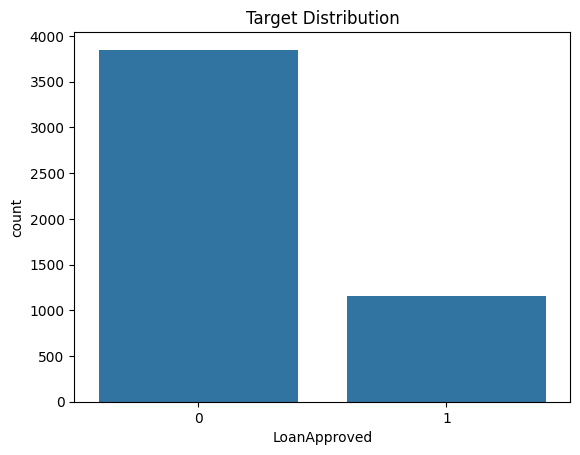

In [9]:
sns.countplot(x="LoanApproved", data=df)
plt.title("Target Distribution")
plt.show()

## DATA CLEANING

In [10]:
df['Income'] = df['Income'].clip(lower=0)

In [11]:
df["LoanAmount"] = df["LoanAmount"].clip(lower=0)

In [12]:
df['Income'].fillna(df['Income'].median(), inplace=True)

In [13]:
df["CreditScore"].fillna(df["CreditScore"].median(), inplace=True)

In [14]:
df['Education'].value_counts()

Education
Bachelors      1220
PhD            1199
Masters        1198
High School    1185
Name: count, dtype: int64

In [15]:
df['Education'].fillna("Unknown", inplace=True)

In [16]:
df.isnull().sum()

Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
Education          0
City               0
EmploymentType     0
LoanApproved       0
dtype: int64

In [17]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,Unknown,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


## ENCODING

In [18]:
df = pd.get_dummies(df, drop_first=True)

## TRAIN TEST SPLIT

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X = df.drop("LoanApproved", axis=1)
y = df['LoanApproved']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [23]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42, class_weight="balanced"),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight="balanced"),
}

best_model = None
best_score = -np.inf
best_model_name = None

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f'{model_name}:')
    print(f'Accuracy: {accuracy:.3f}')
    print(f'F1 Score: {f1:.3f}')
    print(f'ROC-AUC: {roc_auc:.3f}')
    print('----------------------------------------')
    
    if roc_auc > best_score:
        best_score = roc_auc
        best_model = model
        best_model_name = model_name

print(f"Best Model: {best_model_name}")

Random Forest:
Accuracy: 0.964
F1 Score: 0.919
ROC-AUC: 0.937
----------------------------------------
Gradient Boosting:
Accuracy: 0.962
F1 Score: 0.915
ROC-AUC: 0.930
----------------------------------------
Decision Tree:
Accuracy: 0.925
F1 Score: 0.837
ROC-AUC: 0.895
----------------------------------------
Best Model: Random Forest
